In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

customers = pd.read_csv('meridian_customers.csv')
outcomes = pd.read_csv('meridian_outcomes.csv')

# Merge on customer_id

df = customers.merge(outcomes, on='customer_id', how='inner') 
print(f'Shape after merge: {df.shape}') 
print(f'Escalation rate: {df["escalated"].mean():.1%}') 
print(df.info())

Shape after merge: (500, 12)
Escalation rate: 26.8%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          500 non-null    object
 1   age_band             500 non-null    object
 2   product_type         500 non-null    object
 3   region               500 non-null    object
 4   primary_channel      500 non-null    object
 5   tenure_months        500 non-null    int64 
 6   account_value_gbp    500 non-null    int64 
 7   previous_complaints  500 non-null    int64 
 8   escalated            500 non-null    bool  
 9   churned              500 non-null    bool  
 10  complaint_count_12m  500 non-null    int64 
 11  nps_score            500 non-null    int64 
dtypes: bool(2), int64(5), object(5)
memory usage: 40.2+ KB
None


Escalation rate by product:
product_type
Personal Loan      36.5
Home Insurance     31.0
Credit Card        29.6
Current Account    24.2
Savings Account    19.3
Mortgage           18.9
Name: escalated, dtype: float64

Escalation rate by age band:
age_band
18-25    24.2
26-35    30.1
36-45    30.1
46-55    25.0
56-65    21.9
65+      23.9
Name: escalated, dtype: float64

Escalation rate by previous_complaints:
previous_complaints
0    25.6
1    19.5
2    41.1
3    31.2
4    60.0
Name: escalated, dtype: float64


C:\Users\<user>\AppData\Local\Temp\ipykernel_21440\3596475345.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='escalated', y='previous_complaints', ax=axes[1], palette=['#2E5FA3','#E65100'])


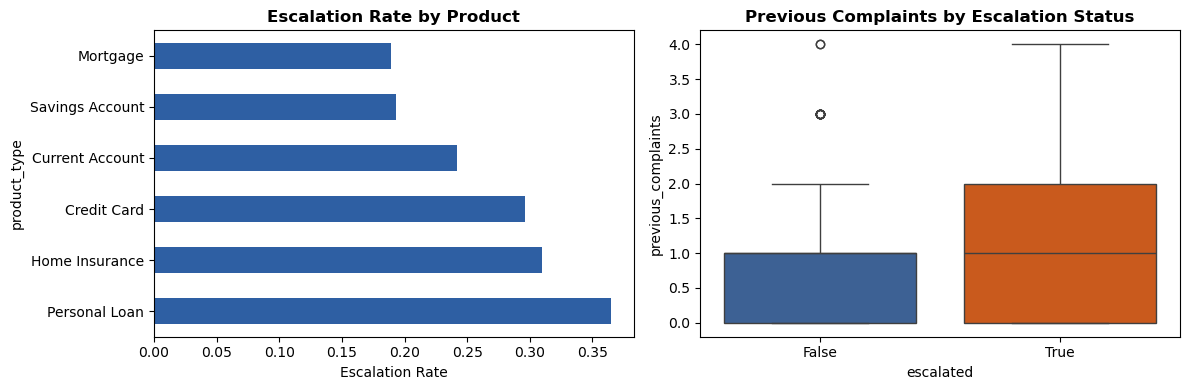

In [2]:
# Escalation rate by product type
prod_esc = df.groupby('product_type')['escalated'].mean().sort_values(ascending=False)
print('Escalation rate by product:')
print((prod_esc * 100).round(1))

# Escalation rate by age band
age_esc = df.groupby('age_band')['escalated'].mean() 
print('\nEscalation rate by age band:')
print((age_esc * 100).round(1))

# Previous complaints vs escalation
print('\nEscalation rate by previous_complaints:') 
print((df.groupby('previous_complaints')['escalated'].mean() * 100).round(1))

# Visualise: escalation rate by product
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
prod_esc.plot(kind='barh', ax=axes[0], color='#2E5FA3') 
axes[0].set_title('Escalation Rate by Product', fontweight='bold')
axes[0].set_xlabel('Escalation Rate')

# Previous complaints boxplot
sns.boxplot(data=df, x='escalated', y='previous_complaints', ax=axes[1], palette=['#2E5FA3','#E65100'])
axes[1].set_title('Previous Complaints by Escalation Status', fontweight='bold')
plt.tight_layout() 
plt.savefig('eda_escalation.png', dpi=150)
plt.show()

In [3]:
#SECTION C * Machine Learning - Escalation Risk Classification

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve)

# Define features and target 
feature_cols = ['tenure_months','account_value_gbp','previous_complaints',
                'age_band','product_type','primary_channel','region'] 
target_col = 'escalated'

# Encode categoricals
df_model = pd.get_dummies(df[feature_cols + [target_col]],
                          columns=['age_band','product_type', 
                                   'primary_channel','region'], 
                          drop_first=True) 
X = df_model.drop(target_col, axis=1)
y = df_model[target_col].astype(int) 

print(f'Features: {X.shape[1]}') 
print(f'Target balance: {y.mean():.1%} escalated')

Features: 22
Target balance: 26.8% escalated


In [5]:
# Split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression (interpretable)
lr_model = LogisticRegression( 
    class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Model 2: Random Forest (higher performance)
rf_model = RandomForestClassifier( 
    n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Evaluate both 
for name, model in [('Logistic Regression', lr_model),
                    ('Random Forest', rf_model)]:
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1] 
    print(f'\n=== {name} ===')
    print(classification_report(y_test, preds,
                                target_names=['Not Escalated','Escalated']))
    print(f'AUC: {roc_auc_score(y_test, proba):.3f}')


=== Logistic Regression ===
               precision    recall  f1-score   support

Not Escalated       0.73      0.48      0.58        73
    Escalated       0.27      0.52      0.35        27

     accuracy                           0.49       100
    macro avg       0.50      0.50      0.47       100
 weighted avg       0.60      0.49      0.52       100

AUC: 0.486

=== Random Forest ===
               precision    recall  f1-score   support

Not Escalated       0.73      0.95      0.82        73
    Escalated       0.20      0.04      0.06        27

     accuracy                           0.70       100
    macro avg       0.46      0.49      0.44       100
 weighted avg       0.58      0.70      0.62       100

AUC: 0.506


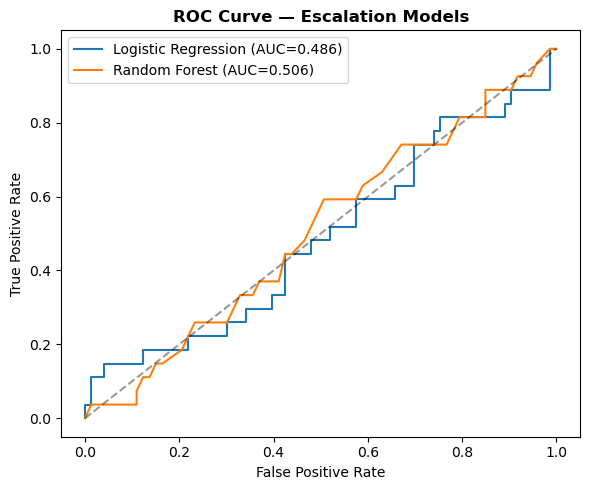

In [6]:
# ROC comparison
plt.figure(figsize=(6,5))
for name, model in [('Logistic Regression', lr_model), ('Random Forest', rf_model)]:
    proba = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test,proba):.3f})')
plt.plot([0,1],[0,1],'k--',alpha=.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Escalation Models', fontweight='bold'); plt.legend(); plt.tight_layout(); plt.show()

In [7]:
# Use your chosen model's probability scores
chosen_model = rf_model # Change to lr_model if you chose Logistic Regression
y_proba = chosen_model.predict_proba(X_test_scaled)[:, 1]

# Test three thresholds
COST_FN = 800 # Cost of missing a high-risk customer (FOS case)
COST_FP = 25 # Cost of unnecessary intervention 

print(f'{'Threshold':<12} {'TP':<6} {'FP':<6} {'FN':<6} {'TN':<6}' 
      f' {'Recall':<8} {'Precision':<12} {'Est Cost GBP'}')
print('-' * 80) 

for thresh in [0.30, 0.40, 0.50]:
    y_pred = (y_proba >= thresh).astype(int) 
    tn,fp,fn,tp = confusion_matrix(y_test, y_pred).ravel() 
    precision = tp / (tp+fp) if (tp+fp)>0 else 0 
    recall = tp / (tp+fn) if (tp+fn)>0 else 0 
    # Scale to full portfolio (test = 20%) 
    total_cost = (fn * COST_FN + fp * COST_FP) * 5 
    print(f'{thresh:<12} {tp:<6} {fp:<6} {fn:<6} {tn:<6}' 
          f' {recall:<8.3f} {precision:<12.3f} GBP {total_cost:,.0f}')

Threshold    TP     FP     FN     TN     Recall   Precision    Est Cost GBP
--------------------------------------------------------------------------------
0.3          12     31     15     42     0.444    0.279        GBP 63,875
0.4          4      12     23     61     0.148    0.250        GBP 93,500
0.5          1      5      26     68     0.037    0.167        GBP 104,625


In [8]:
#SECTION D * NLP - Understanding What Customers Are Actually Saying

In [9]:
#Path A- Azure cognitive Services

In [10]:
!pip install azure-ai-textanalytics

In [11]:
# Install: pip install azure-ai-textanalytics
from azure.ai.textanalytics import TextAnalyticsClient 

from azure.core.credentials import AzureKeyCredential 
# Replace with your actual endpoint and key 
ENDPOINT = 'https://<your-resource>.cognitiveservices.azure.com/' 
KEY = '<your-azure-language-key>'  # never commit real keys 

client = TextAnalyticsClient(
    endpoint=ENDPOINT, 
    credential=AzureKeyCredential(KEY)
) 

# Load a sample of ticket texts (Azure free tier: 5,000 requests)
tickets = pd.read_csv('meridian_tickets.csv') 
sample = tickets.head(100) # Start with 100 records


# Run sentiment analysis in batches of 10 (Azure limit)
docs = list(sample['ticket_text'])

sentiments = []
batch_size = 10

for i in range(0, len(docs), batch_size):
    batch = docs[i:i + batch_size]
    results = client.analyze_sentiment(documents=batch)
    for doc in results:
        if not doc.is_error:
            sentiments.append({
                'sentiment': doc.sentiment,
                'positive_score': doc.confidence_scores.positive,
                'neutral_score': doc.confidence_scores.neutral,
                'negative_score': doc.confidence_scores.negative,
            })

sentiment_df = pd.DataFrame(sentiments)
print(sentiment_df['sentiment'].value_counts())


sentiment
negative    63
neutral     36
positive     1
Name: count, dtype: int64


                         phrase  count
0                       account     23
1         home insurance policy      9
2                        excess      9
3               billing dispute      7
4                   monthly fee      6
5                  notification      6
6        early repayment charge      5
7                          loan      5
8            unexplained charge      5
9                  last Tuesday      5
10             worst experience      5
11            financial company      5
12  multiple small transactions      4
13                 credit limit      4
14                      process      4
15                        terms      4
16                     mortgage      4
17                 direct debit      4
18                   wrong date      4
19               online banking      3


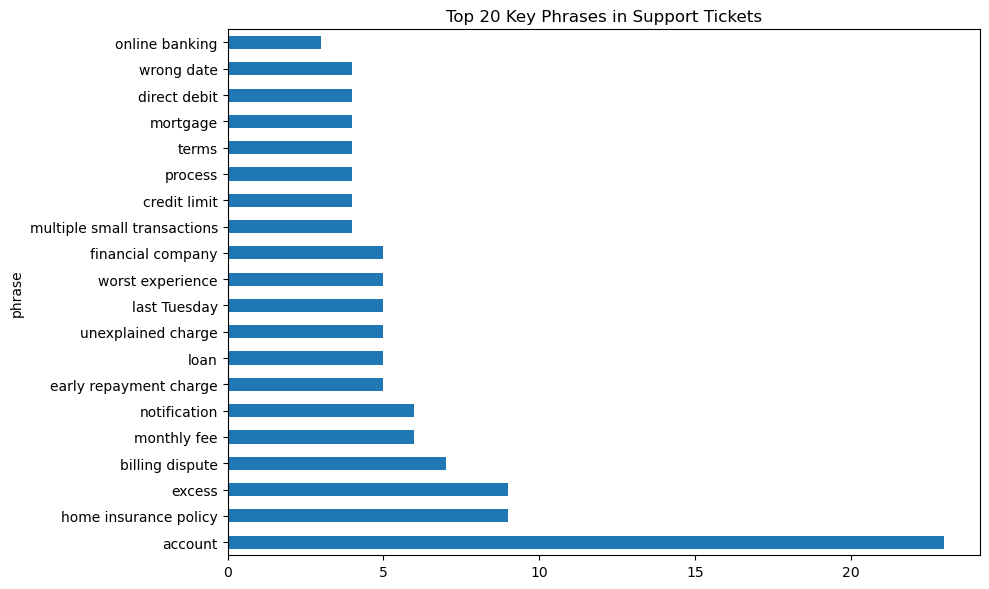

In [12]:
# Extract key phrases in batches of 10 (Azure limit)
all_phrases = []
batch_size = 10

for i in range(0, len(docs), batch_size):
    batch = docs[i:i + batch_size]
    kp_results = client.extract_key_phrases(documents=batch)
    for doc in kp_results:
        if not doc.is_error:
            all_phrases.extend(doc.key_phrases)

# Count most common key phrases
from collections import Counter
phrase_counts = Counter(all_phrases)
top_phrases = pd.DataFrame(phrase_counts.most_common(20),
                           columns=['phrase', 'count'])
print(top_phrases)

# Bar chart of top phrases
top_phrases.set_index('phrase')['count'].plot(kind='barh', figsize=(10,6))
plt.title('Top 20 Key Phrases in Support Tickets')
plt.tight_layout()
plt.savefig('key_phrases.png', dpi=150)
plt.show()

In [13]:
#Path B- Python open-Source NLP

In [14]:
%pip install vaderSentiment

In [15]:
import sys
!"{sys.executable}" -m pip install vaderSentiment

In [16]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
analyser = SentimentIntensityAnalyzer()
tickets = pd.read_csv('meridian_tickets.csv')
reviews = pd.read_csv('meridian_reviews.csv')

def score_sentiment(text):
    s = analyser.polarity_scores(str(text))['compound']
    if s >= 0.05: return 'positive', s
    elif s <= -0.05: return 'negative', s
    return 'neutral', s
tickets[['sentiment','compound_score']] = tickets['ticket_text'].apply(lambda t: pd.Series(score_sentiment(t)))
print(tickets['sentiment'].value_counts())
print(f"Avg compound score: {tickets['compound_score'].mean():.3f}")

sentiment
neutral     417
negative    344
positive    158
Name: count, dtype: int64
Avg compound score: -0.069


In [17]:
#Output 1 — Sentiment distribution.

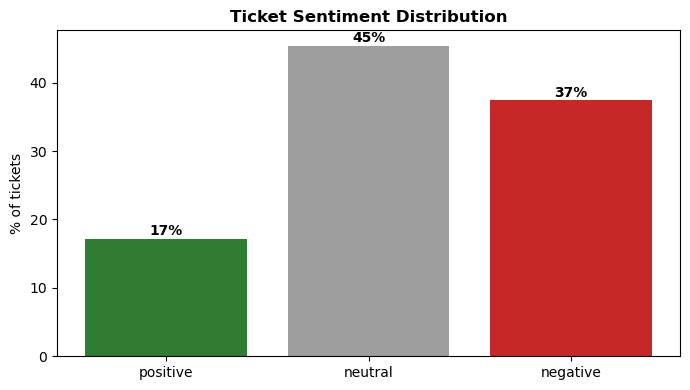

In [18]:
import matplotlib.pyplot as plt
order=['positive','neutral','negative']
vals=[(tickets['sentiment']==s).mean()*100 for s in order]
plt.figure(figsize=(7,4)); plt.bar(order, vals, color=['#2E7D32','#9E9E9E','#C62828'])
for i,v in enumerate(vals): plt.text(i, v+0.5, f'{v:.0f}%', ha='center', fontweight='bold')
plt.title('Ticket Sentiment Distribution', fontweight='bold'); plt.ylabel('% of tickets'); plt.tight_layout(); plt.show()

In [19]:
#Output 2 — Sentiment by ticket category.

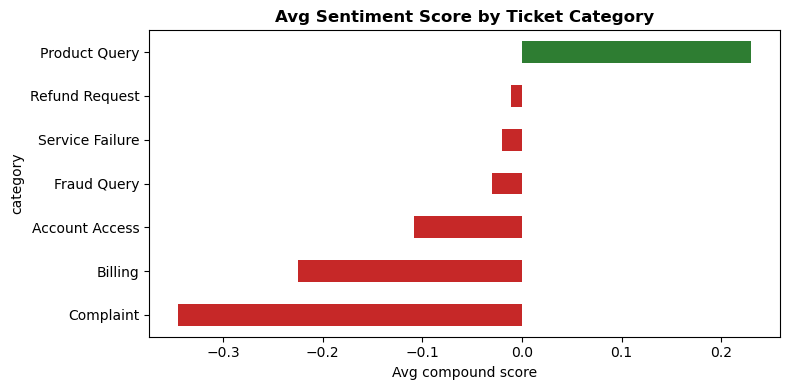

category
Product Query      191
Billing            180
Account Access     165
Complaint          124
Fraud Query        115
Service Failure     96
Refund Request      48
Name: count, dtype: int64


In [20]:
cat_sent = tickets.groupby('category')['compound_score'].mean().sort_values()
plt.figure(figsize=(8,4))
cat_sent.plot(kind='barh', color=['#C62828' if v<0 else '#2E7D32' for v in cat_sent])
plt.title('Avg Sentiment Score by Ticket Category', fontweight='bold'); plt.xlabel('Avg compound score'); plt.tight_layout(); plt.show()
print(tickets['category'].value_counts())

In [21]:
#Output 3 — Sentiment vs escalation.

In [22]:
print("TICKETS columns:", list(tickets.columns))
print("REVIEWS columns:", list(reviews.columns))

TICKETS columns: ['ticket_id', 'customer_id', 'ticket_date', 'category', 'resolution_time_hrs', 'resolved', 'ticket_text', 'sentiment', 'compound_score']
REVIEWS columns: ['review_id', 'customer_id', 'review_date', 'star_rating', 'product_type', 'review_text']


C:\Users\<user>\AppData\Local\Temp\ipykernel_21440\2436344795.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tk, x='resolved', y='compound_score', palette=['orange','blue'])


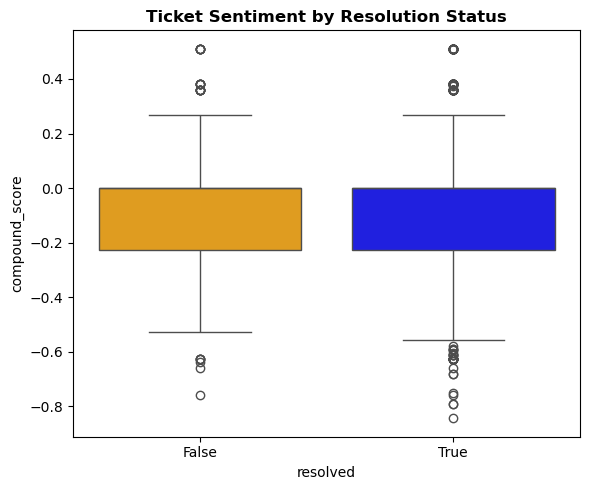

resolved
False   -0.068
True    -0.069
Name: compound_score, dtype: float64


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

tk = tickets.dropna(subset=['resolved'])
plt.figure(figsize=(6,5))
sns.boxplot(data=tk, x='resolved', y='compound_score', palette=['orange','blue'])
plt.title('Ticket Sentiment by Resolution Status', fontweight='bold')
plt.tight_layout(); plt.show()

print(tk.groupby('resolved')['compound_score'].mean().round(3))

In [24]:
#Output 4 — Top key phrases. 

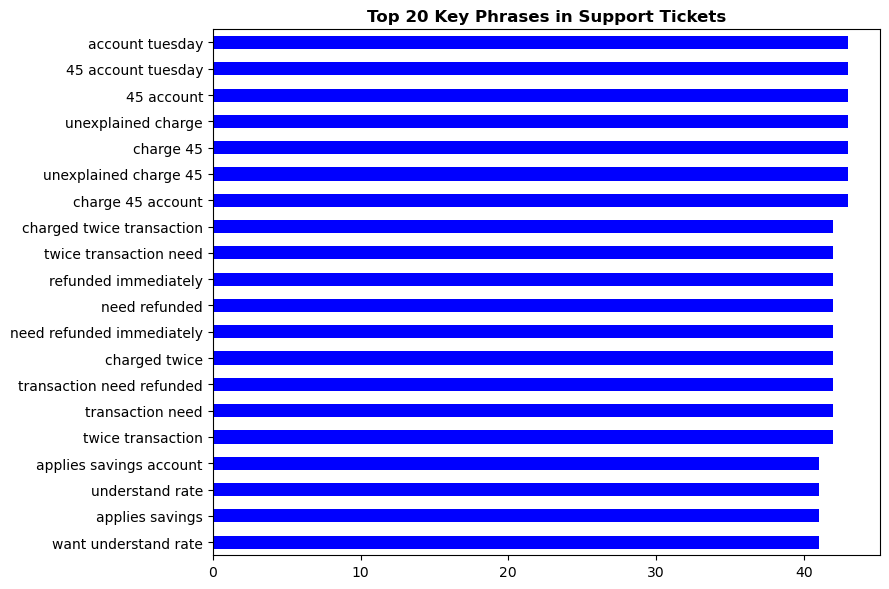

In [25]:
import numpy as np 
vec = CountVectorizer(ngram_range=(2,3), stop_words='english', min_df=3)
mat = vec.fit_transform(tickets['ticket_text'].astype(str))
freqs = np.asarray(mat.sum(axis=0)).ravel()
phrases = pd.Series(freqs, index=vec.get_feature_names_out()).sort_values(ascending=False).head(20)
plt.figure(figsize=(9,6)); phrases.sort_values().plot(kind='barh', color='blue')
plt.title('Top 20 Key Phrases in Support Tickets', fontweight='bold'); plt.tight_layout(); plt.show()

In [26]:
#Output 5 — Review rating over time.

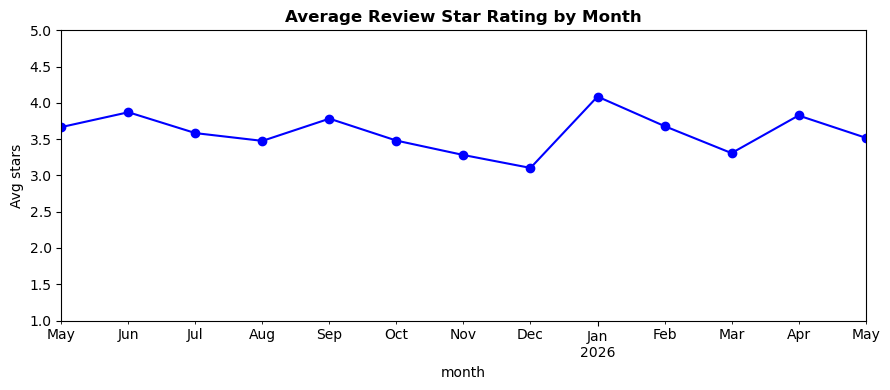

First month: 3.67 | Last month: 3.52


In [27]:
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
reviews['month'] = reviews['review_date'].dt.to_period('M').dt.to_timestamp()
monthly = reviews.groupby('month')['star_rating'].mean()
plt.figure(figsize=(9,4)); monthly.plot(marker='o', color='blue')
plt.title('Average Review Star Rating by Month', fontweight='bold'); plt.ylabel('Avg stars'); plt.ylim(1,5); plt.tight_layout(); plt.show()
print('First month:', round(monthly.iloc[0],2), '| Last month:', round(monthly.iloc[-1],2))

In [28]:
#SECTION E * Responsible AI - Bias Audit and Fairness Assessment

In [29]:
# Rebuild test set with original features for filtering
test_idx = X_test.index
df_test = df.loc[test_idx].copy() 
df_test['y_pred'] = chosen_model.predict(X_test_scaled)
df_test['y_proba'] = chosen_model.predict_proba(X_test_scaled)[:, 1]
df_test['y_true'] = y_test.values

# Accuracy and recall by age band 
print('=== Model Performance by Age Band ===') 
for band in df_test['age_band'].unique(): 
    subset = df_test[df_test['age_band'] == band]
    if len(subset) == 0: continue 
    acc = (subset['y_true'] == subset['y_pred']).mean() 
    recall = (subset[(subset['y_true']==1)]['y_pred']==1).mean()
    n_pos = (subset['y_true']==1).sum() 
    print(f' {band:<10} n={len(subset):<4} '+
         f'accuracy={acc:.3f} recall={recall:.3f} '+ 
         f'true positives={n_pos}')

# Same by product type
print('\n=== Model Performance by Product Type ===') 
for prod in df_test['product_type'].unique(): 
    subset = df_test[df_test['product_type'] == prod] 
    if len(subset) == 0: continue 
    acc = (subset['y_true'] == subset['y_pred']).mean() 
    recall = (subset[(subset['y_true']==1)]['y_pred']==1).mean() 
    print(f' {prod:<20} n={len(subset):<4} '+ 
          f'accuracy={acc:.3f} recall={recall:.3f}')

=== Model Performance by Age Band ===
 56-65      n=12   accuracy=0.917 recall=0.000 true positives=1
 26-35      n=21   accuracy=0.714 recall=0.000 true positives=5
 46-55      n=23   accuracy=0.696 recall=0.000 true positives=5
 65+        n=8    accuracy=0.625 recall=0.000 true positives=3
 36-45      n=22   accuracy=0.591 recall=0.111 true positives=9
 18-25      n=14   accuracy=0.714 recall=0.000 true positives=4

=== Model Performance by Product Type ===
 Credit Card          n=15   accuracy=0.600 recall=0.000
 Mortgage             n=8    accuracy=1.000 recall=nan
 Home Insurance       n=12   accuracy=0.667 recall=0.000
 Current Account      n=30   accuracy=0.700 recall=0.000
 Personal Loan        n=16   accuracy=0.750 recall=0.200
 Savings Account      n=19   accuracy=0.632 recall=0.000


In [30]:
# False Positive Rate = FP / (FP + TN) for each group
# = fraction of non-escalating customers incorrectly flagged
print('=== False Positive Rate by Age Band ===') 
for band in sorted(df_test['age_band'].unique()):
    subset = df_test[df_test['age_band'] == band]
    negatives = subset[subset['y_true'] == 0]
    if len(negatives) == 0: continue 
    fpr = (negatives['y_pred'] == 1).mean() 
    actual_esc = (subset['y_true'] == 1).mean() 
    print(f' {band:<10} FPR={fpr:.3f} actual_esc_rate={actual_esc:.3f}')

=== False Positive Rate by Age Band ===
 18-25      FPR=0.000 actual_esc_rate=0.286
 26-35      FPR=0.062 actual_esc_rate=0.238
 36-45      FPR=0.077 actual_esc_rate=0.409
 46-55      FPR=0.111 actual_esc_rate=0.217
 56-65      FPR=0.000 actual_esc_rate=0.083
 65+        FPR=0.000 actual_esc_rate=0.375


In [31]:
#SECTION F * THE TWIST - The FCA Explainability Requirement

In [32]:
%pip install shap

<Figure size 1000x600 with 0 Axes>

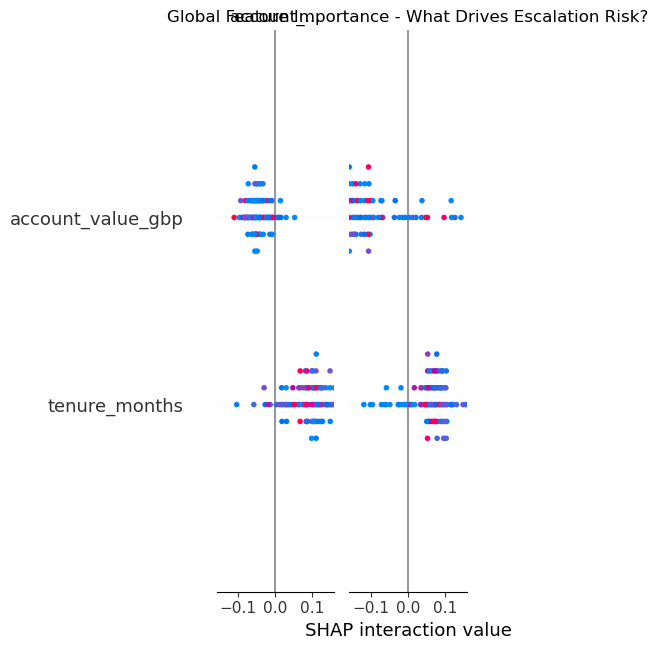

In [33]:
# Install: pip install shap
import shap

# Create explainer for your chosen model
# TreeExplainer is fastest for Random Forest
# LinearExplainer is best for Logistic Regression 

if hasattr(chosen_model, 'estimators_'): # Random Forest
    explainer = shap.TreeExplainer(chosen_model) 
    shap_values = explainer.shap_values(X_test_scaled)
    # For binary classification, take class 1 (escalated) 
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values 
else: # Logistic Regression 
    explainer = shap.LinearExplainer(chosen_model,
                                     X_train_scaled) 
shap_values = explainer.shap_values(X_test_scaled) 
sv = shap_values 

# Global summary: which features drive escalation most?
plt.figure(figsize=(10, 6)) 
shap.summary_plot(sv, X_test_scaled,
                  feature_names=X.columns.tolist(), 
                  plot_type='bar', show=False)
plt.title('Global Feature Importance - What Drives Escalation Risk?') 
plt.tight_layout() 
plt.savefig('shap_global.png', dpi=150)
plt.show()

TP: 70   FP: 6   FN: 9


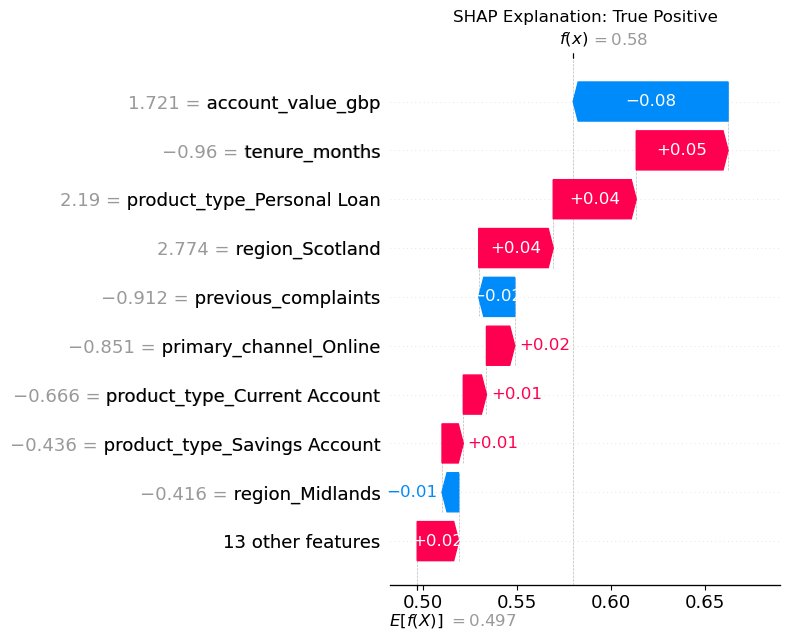

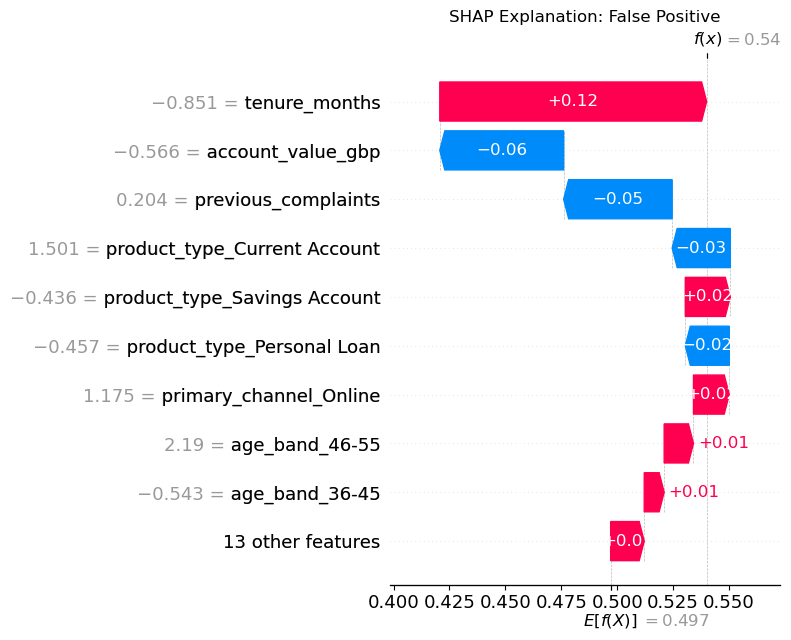

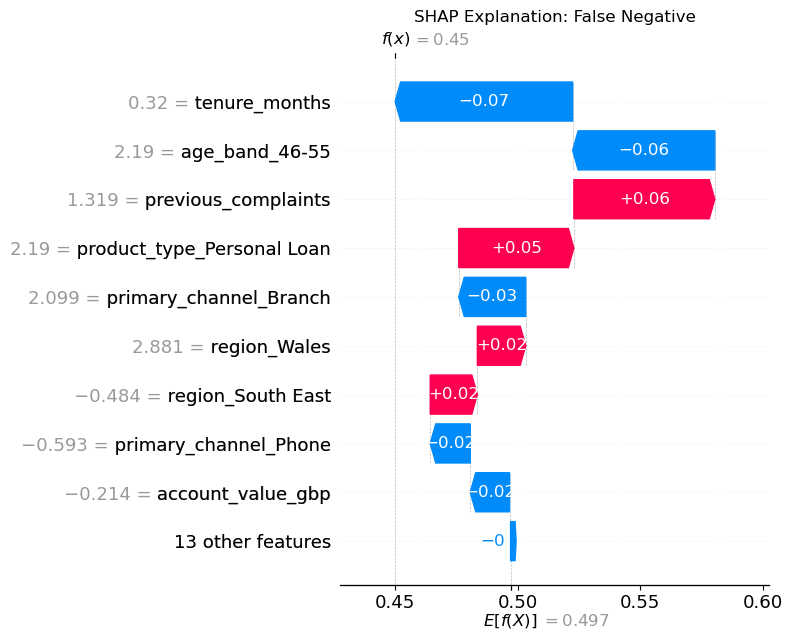

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# ── 1. SHAP values (keep your existing setup if these lines differ) ──
explainer  = shap.TreeExplainer(model)            # ← your trained model's name
shap_values = explainer.shap_values(X_test_scaled)

# Normalise to the positive class (escalation = 1)
sv = np.array(shap_values)
if sv.ndim == 3:
    sv_arr = sv[1] if sv.shape[0] == 2 else sv[:, :, 1]
else:
    sv_arr = sv

base = np.array(explainer.expected_value).ravel()
base = float(base[1]) if base.size > 1 else float(base[0])

# ── 2. Find one example each: TP, FP, FN ──
y_true = np.array(y_test).ravel()      # ← your test labels
y_hat  = np.array(y_pred).ravel()      # ← your model predictions

def first_match(true_val, pred_val):
    hits = np.where((y_true == true_val) & (y_hat == pred_val))[0]
    return int(hits[0]) if len(hits) else None

tp_idx = first_match(1, 1)   # escalated,     predicted escalate
fp_idx = first_match(0, 1)   # not escalated, predicted escalate (false alarm)
fn_idx = first_match(1, 0)   # escalated,     predicted no        (missed)
print("TP:", tp_idx, "  FP:", fp_idx, "  FN:", fn_idx)

# ── 3. Waterfall plot for each ──
for label, idx in [('True Positive',  tp_idx),
                   ('False Positive', fp_idx),
                   ('False Negative', fn_idx)]:
    if idx is None:
        print(f"No {label} example in the test set — skipping.")
        continue
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(
        shap.Explanation(
            values=sv_arr[idx],
            base_values=base,
            data=X_test_scaled[idx],
            feature_names=X.columns.tolist()
        ),
        show=False
    )
    plt.title(f'SHAP Explanation: {label}')
    plt.tight_layout()
    plt.show()

In [35]:
#SECTION G * Power BI AI Insights Dashboard

In [36]:
# Export: customer profiles + ML risk scores + NLP sentiment + outcomes
# Join everything on customer_id

# ML outputs
df_test['risk_score_pct'] = (df_test['y_proba'] * 100).round(1)
df_test['risk_band'] = pd.cut(
    df_test['y_proba'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Combine with customer profile for Power BI
export_df = df_test[[
    'customer_id','age_band','product_type','region',
    'primary_channel','tenure_months','account_value_gbp',
    'previous_complaints','risk_score_pct','risk_band',
    'y_true','y_pred','escalated','churned','nps_score'
]].copy()

export_df.to_csv('meridian_ml_output.csv', index=False)

# Also export sentiment results
# (join your sentiment_df to tickets and export) 
tickets['sentiment_score'] = tickets['ticket_text'].apply(
    lambda t: analyser.polarity_scores(str(t))['compound']) 
tickets.to_csv('meridian_nlp_output.csv', index=False)


print(f'ML output: {len(export_df)} rows')
print(f'NLP output: {len(tickets)} rows')
print(export_df['risk_band'].value_counts())

ML output: 100 rows
NLP output: 919 rows
risk_band
Low Risk       60
Medium Risk    40
High Risk       0
Name: count, dtype: int64


In [37]:
# Score the FULL dataset, not just the test split
X_all_scaled = scaler.transform(X)            # X = all features
df_all = df.copy()
df_all['y_proba'] = chosen_model.predict_proba(X_all_scaled)[:, 1]
df_all['y_pred']  = chosen_model.predict(X_all_scaled)
df_all['y_true']  = y.values

df_all['risk_score_pct'] = (df_all['y_proba'] * 100).round(1)
df_all['risk_band'] = pd.cut(df_all['y_proba'],
        bins=[0, 0.3, 0.6, 1.0],
        labels=['Low Risk', 'Medium Risk', 'High Risk'])

export_df = df_all[['customer_id','age_band','product_type','region',
    'primary_channel','tenure_months','account_value_gbp',
    'previous_complaints','risk_score_pct','risk_band',
    'y_true','y_pred','escalated','churned','nps_score']].copy()
export_df.to_csv('meridian_ml_output.csv', index=False)

tickets['sentiment_score'] = tickets['ticket_text'].apply(
    lambda t: analyser.polarity_scores(str(t))['compound'])
tickets.to_csv('meridian_nlp_output.csv', index=False)
print('ML rows:', len(export_df), '| NLP rows:', len(tickets))


ML rows: 500 | NLP rows: 919


In [38]:
export_df.to_csv('meridian_ml_output.csv', index=False)
tickets.to_csv('meridian_nlp_output.csv', index=False)